In [ ]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

from sklearn.linear_model import LinearRegression

In [19]:
dfa = pd.read_csv('sample_data/Advertising.csv')
# data = data[['TV','Sales']]
dfa.head(10)

,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9
5,8.7,48.9,75.0,7.2
6,57.5,32.8,23.5,11.8
7,120.2,19.6,11.6,13.2
8,8.6,2.1,1.0,4.8
9,199.8,2.6,21.2,10.6


In [ ]:
data = pd.read_csv('sample_data/Advertising.csv')
data = data[['TV','Sales']]
data.head(10)

,TV,Sales
0,230.1,22.1
1,44.5,10.4
2,17.2,9.3
3,151.5,18.5
4,180.8,12.9
5,8.7,7.2
6,57.5,11.8
7,120.2,13.2
8,8.6,4.8
9,199.8,10.6


Text(0, 0.5, 'Sales')

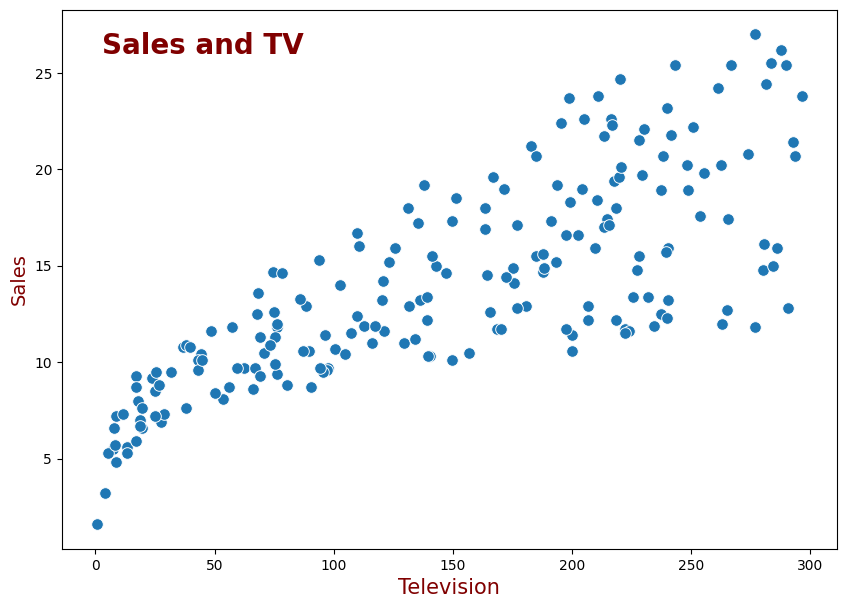

In [ ]:
fig, ax = plt.subplots(figsize=(10,7))
sns.scatterplot(x='TV', y='Sales', data=data, s=70)

title = 'Sales and TV'
ax.text(45,26,title,horizontalalignment='center',color='#800000',fontsize=20,fontweight='bold')

ax.set_xlabel('Television', fontsize=15, color='#800000')
ax.set_ylabel('Sales', fontsize=14, color='#800000')


In [ ]:
data.columns = ['x','y']
data.head()

,x,y
0,230.1,22.1
1,44.5,10.4
2,17.2,9.3
3,151.5,18.5
4,180.8,12.9


In [ ]:
# x -> fitur
# y -> target

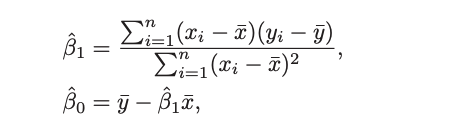

In [ ]:
data['x'].mean(), data['y'].mean()

(np.float64(147.0425), np.float64(14.0225))

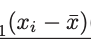

In [ ]:
data['(x-x_mean)'] = round(data['x'] - data['x'].mean(),2)
data.head()

,x,y,(x-x_mean)
0,230.1,22.1,83.06
1,44.5,10.4,-102.54
2,17.2,9.3,-129.84
3,151.5,18.5,4.46
4,180.8,12.9,33.76


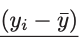

In [ ]:
data['(y-y_mean)'] = round(data['y'] - data['y'].mean(),2)
data.head()

,x,y,(x-x_mean),(y-y_mean)
0,230.1,22.1,83.06,8.08
1,44.5,10.4,-102.54,-3.62
2,17.2,9.3,-129.84,-4.72
3,151.5,18.5,4.46,4.48
4,180.8,12.9,33.76,-1.12


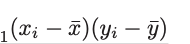

In [ ]:
data['(x-x_mean)(y-y_mean)'] = data['(x-x_mean)'] * data['(y-y_mean)']
data.head()

,x,y,(x-x_mean),(y-y_mean),(x-x_mean)(y-y_mean)
0,230.1,22.1,83.06,8.08,671.1248
1,44.5,10.4,-102.54,-3.62,371.1948
2,17.2,9.3,-129.84,-4.72,612.8448
3,151.5,18.5,4.46,4.48,19.9808
4,180.8,12.9,33.76,-1.12,-37.8112


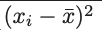

In [ ]:
data['pow((x-x_mean),2)'] = round(pow(data['x'] - data['x'].mean(),2),2)
data.head()

,x,y,(x-x_mean),(y-y_mean),(x-x_mean)(y-y_mean),"pow((x-x_mean),2)"
0,230.1,22.1,83.06,8.08,671.1248,6898.55
1,44.5,10.4,-102.54,-3.62,371.1948,10514.96
2,17.2,9.3,-129.84,-4.72,612.8448,16859.07
3,151.5,18.5,4.46,4.48,19.9808,19.87
4,180.8,12.9,33.76,-1.12,-37.8112,1139.57


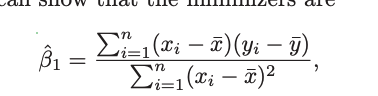

In [13]:
b1 = data['(x-x_mean)(y-y_mean)'].sum() / data['pow((x-x_mean),2)'].sum()
b1

np.float64(0.047536644161412324)

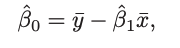

In [14]:
b0 = data['y'].mean() - b1 * data['x'].mean()
b0

np.float64(7.032593000895529)

In [22]:
data['y_pred'] = b0 + (b1*data['x'])
data['residual'] = data['y'] - data['y_pred']
data.head(10)

,x,y,(x-x_mean),(y-y_mean),(x-x_mean)(y-y_mean),"pow((x-x_mean),2)",y_pred,residual
0,230.1,22.1,83.06,8.08,671.1248,6898.55,18.0778,4.0222
1,44.5,10.4,-102.54,-3.62,371.1948,10514.96,9.1690,1.2310
2,17.2,9.3,-129.84,-4.72,612.8448,16859.07,7.8586,1.4414
3,151.5,18.5,4.46,4.48,19.9808,19.87,14.3050,4.1950
4,180.8,12.9,33.76,-1.12,-37.8112,1139.57,15.7114,-2.8114
5,8.7,7.2,-138.34,-6.82,943.4788,19138.65,7.4506,-0.2506
6,57.5,11.8,-89.54,-2.22,198.7788,8017.86,9.7930,2.0070
7,120.2,13.2,-26.84,-0.82,22.0088,720.52,12.8026,0.3974
8,8.6,4.8,-138.44,-9.22,1276.4168,19166.33,7.4458,-2.6458
9,199.8,10.6,52.76,-3.42,-180.4392,2783.35,16.6234,-6.0234


In [16]:
# y = b0 + b1*x1
# y = b0 + (b1*TV)
# y = 7.03 + (0.047 * TV)

y = 7.03 + (0.047 * 10)
y

7.5

In [17]:
y = 7.03 + (0.047 * 100)
y

11.73

In [18]:
x = data.x.values.reshape(-1,1)
y = data.y.values.reshape(-1,1)

from sklearn.linear_model import LinearRegression
model = LinearRegression().fit(x, y)

b0 = float(model.intercept_[0])
b0 = round(b0,3)
b1 = float(model.coef_[0][0])
b1 = round(b1,3)
print('intercept (b0 ): ', b0)
print('slope (b1) : ', b1)
print(' ')
textstr = 'y = '+str(b0)+' + '+str(b1)+' * x'
print(textstr)

intercept (b0 ):  7.033
slope (b1) :  0.048
 
y = 7.033 + 0.048 * x
